# Family Model - Base Model

This notebook showcases our pipeline in action, for the "family" label classification task. This is our baseline model after the application of image cleaning, oversampling and resize, which were all handled in offline routines.

## Imports

The imports are composed of a mix of third-party libraries and several modules and constants that we have custom built to fit our needs.

In [3]:
# Standard Library
import os
from datetime import date

# Third-party libraries
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # type: ignore
from tensorflow.keras.metrics import AUC # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator, smart_resize  # type: ignore
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import model_from_json 
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Internal modules
from deep.constants import BATCH_SIZE, INPUT_DIR, METADATA_DIR, METADATA_FILE, MODEL_IMAGE_SIZE, SEEDS, MODELS, MODEL_CONFIGS
from deep.modelling.metric_utils import get_fitted_model_metrics, plot_metrics, plot_confusion_matrix
from deep.modelling.pipiline_utils import split_data
from deep.preprocess.album_augmenter import compute_effective_class_weights
from deep.modelling.custom_loss import CategoricalFocalLoss
from deep.modelling.model_specifications import efficient_net_deep

2025-05-01 23:08:08.973070: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-01 23:08:08.973783: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-01 23:08:08.977128: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-01 23:08:08.985510: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746137289.002658   20061 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746137289.00

## Loading Metadata and Splits

The foremost task is to obtain the metadata for our image files.

In [4]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum','is_animal'], inplace=True)

data

,rare_species_id,family,file_path
0,75fd91cb-2881-41cd-88e6-de451e8b60e2,unionidae,12853737_449393.jpg
1,28c508bc-63ff-4e60-9c8f-1934367e1528,geoemydidae,20969394_793083.jpg
2,00372441-588c-4af8-9665-29bee20822c0,cryptobranchidae,28895411_319982.jpg
3,29cc6040-6af2-49ee-86ec-ab7d89793828,turdidae,29658536_45510188.jpg
4,94004bff-3a33-4758-8125-bf72e6e57eab,indriidae,21252576_7250886.jpg
...,...,...,...
11978,1fa96ea5-32fa-4a25-b8d2-fa99f6e2cb89,leporidae,29734618_1011315.jpg
11979,628bf2b4-6ecc-4017-a8e6-4306849e0cfc,emydidae,29972861_1056842.jpg
11980,0ecfdec9-b1cd-4d43-96fc-2f8889ec1ad9,dasyatidae,30134195_52572074.jpg
11981,27fdb1e9-c5fb-459a-8b6a-6fb222b1c512,mustelidae,9474963_46559139.jpg


In [5]:
# Splitting the indices
train_df, val_df, test_df = split_data(data, 'family', seed=SEEDS[0], save_split=True)

In [6]:
upsampled = pd.read_csv(f'{METADATA_DIR}/family_upsample.csv')
upsampled

,rare_species_id,file_path,family
0,5a259dbb-e7b1-4485-9517-0fb0aa4a069d,14177753_45511531_accipitridae_rotate_30.jpg,accipitridae
1,5f151629-52f4-498f-8a7f-2a4a93dd9c32,30098505_205909_acipenseridae_rotate_30.jpg,acipenseridae
2,d54d7e19-5211-4bad-9cd8-55c3fab1a45c,28233665_205910_acipenseridae_rotate_30.jpg,acipenseridae
3,f362292e-1547-45b5-981c-08dbae0aa6a2,29619954_46561170_acipenseridae_rotate_30.jpg,acipenseridae
4,a1f99903-9a82-4873-b791-32f6b4353201,29537902_205910_acipenseridae_rotate_30.jpg,acipenseridae
...,...,...,...
55226,27ddf055-03fa-4f18-9c5c-8a0c72fc563b,20663362_205714_siluridae_flip_lr.jpg,siluridae
55227,595aa95e-78c3-49df-b421-e8bfd8181a06,28985463_205714_siluridae_bright_plus.jpg,siluridae
55228,e3ffb421-da44-4844-ad66-ea1e3814e88f,28985469_205714_siluridae_bright_plus.jpg,siluridae
55229,27ddf055-03fa-4f18-9c5c-8a0c72fc563b,20663362_205714_siluridae_bright_plus.jpg,siluridae


Per our framework, the oversamples that we created before and stored can be accessed by a common key with the main metadata.csv, and simply concatenated.

In [7]:
# Slice upsample with the selected indices 
aux_df = upsampled[upsampled['rare_species_id'].isin(train_df['rare_species_id'])]

# Update the metadata with the selected upsample indices
train_df = pd.concat([train_df,aux_df], ignore_index=True, axis=0)

# Looks good
train_df

,rare_species_id,family,file_path
0,002cf717-3a67-42c8-b855-cf8b2c4d6bd7,syngnathidae,2718903_46567771.jpg
1,26500c41-df95-4239-8e3e-b891c3d05458,iguanidae,29033055_963751.jpg
2,a35643c2-38cf-4712-a900-052d2528d713,pardalotidae,21055048_45518587.jpg
3,160213c1-306b-4be4-9c55-244fb0556e35,hylobatidae,28417389_326451.jpg
4,726e1436-5185-40cc-9e2a-38cf24791c9c,faviidae,28312775_45276847.jpg
...,...,...,...
45687,febd5527-ff11-4c12-8a21-a7416f9df934,siluridae,20663361_205714_siluridae_flip_lr.jpg
45688,27ddf055-03fa-4f18-9c5c-8a0c72fc563b,siluridae,20663362_205714_siluridae_flip_lr.jpg
45689,e3ffb421-da44-4844-ad66-ea1e3814e88f,siluridae,28985469_205714_siluridae_bright_plus.jpg
45690,27ddf055-03fa-4f18-9c5c-8a0c72fc563b,siluridae,20663362_205714_siluridae_bright_plus.jpg


## Image Generator

Image generator is setup with conservative values, as animal features like faces are not invariant under rotation. Test images were standardized according to the IMAGENET standard.

In [8]:
# Image Generator
train_datagen = ImageDataGenerator(
        rotation_range=90,
        shear_range=0.2,
        brightness_range=[0.8, 1.2],
        horizontal_flip=True,
        channel_shift_range=30.0,
        zoom_range=(0.8, 1.2),
        fill_mode='nearest',
        preprocessing_function=lambda image: smart_resize(image, size=MODEL_IMAGE_SIZE['efficientnetb4'])
    )

test_datagen = ImageDataGenerator(
        preprocessing_function=lambda image: smart_resize(image, size=MODEL_IMAGE_SIZE['efficientnetb4'])
    )

**Note: we were unable to debug the issue shown above with 232 images, however it was deemed to not be a source of data leakage, as far as we can diagnose it. .**

## Flow_from

Flow from dataframe along side each generator setup for each of the data splits.

In [9]:
# Train generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=INPUT_DIR,
    x_col='file_path',
    y_col='family',
    target_size=MODEL_IMAGE_SIZE['efficientnetb4'],
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEEDS[0],
    shuffle=True
)

# Validation generator
val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=INPUT_DIR,
    x_col='file_path',
    y_col='family',
    target_size=MODEL_IMAGE_SIZE['efficientnetb4'],
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Test generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=INPUT_DIR,
    x_col='file_path',
    y_col='family',
    target_size=MODEL_IMAGE_SIZE['efficientnetb4'],
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 45692 validated image filenames belonging to 202 classes.
Found 1438 validated image filenames belonging to 202 classes.
Found 2397 validated image filenames belonging to 202 classes.


## Weights

Our loss function of choice was the MultiClass Focal Loss, a derivation of the Focal Loss.

In [10]:
# Map class weights from labels - indices using the generator
label_map = train_generator.class_indices
weights_str = compute_effective_class_weights(train_df, 'family')
weights_idx = {label_map[k]: v for k, v in weights_str.items()}

# Convert to list for alpha
alpha = [weights_idx[i] for i in range(len(weights_idx))]

# Instantiate focal loss
loss = CategoricalFocalLoss(gamma=5, alpha=alpha)

num_classes = train_df['family'].nunique()

## Model and Weights Loading

Our model is then instanced, and compiled, RMSprop was found to be a stable option.

In [11]:
# Load the model architecture from the JSON file
with open(os.path.join(MODEL_CONFIGS, 'model_base_architecture_2025-04-30.json'), 'r') as json_file:
    model_json = json_file.read()

model = model_from_json(model_json, custom_objects={'CategoricalFocalLoss': loss})

# Load the model weights
model.load_weights(os.path.join(MODELS, 'BASE_MODEL_00.weights.h5'))


2025-05-01 23:08:17.586901: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Evaluate Model

### Test metrics

Predict the test set via test generator, and then evaluate the results.

In [12]:
# Predicting results on the test set
y_pred_proba = model.predict(test_generator, steps=len(test_generator), verbose=1)

# Obtaining our classification metadata
y_pred_classes = np.argmax(y_pred_proba, axis=1)
y_true_classes = test_generator.classes
class_indices = test_generator.class_indices
class_labels = list(class_indices.keys())

/home/nottoriousgg/miniconda3/envs/deep/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step


In [23]:
list(class_indices.values())

['accipitridae',
 'acipenseridae',
 'acroporidae',
 'agamidae',
 'agariciidae',
 'albulidae',
 'alcedinidae',
 'alligatoridae',
 'alopiidae',
 'ambystomatidae',
 'anatidae',
 'anguidae',
 'aotidae',
 'apidae',
 'ardeidae',
 'arthroleptidae',
 'atelidae',
 'attelabidae',
 'balaenicipitidae',
 'balaenidae',
 'balaenopteridae',
 'balistidae',
 'bombycillidae',
 'bovidae',
 'brachypteraciidae',
 'bucerotidae',
 'bufonidae',
 'burhinidae',
 'cacatuidae',
 'callitrichidae',
 'callorhinchidae',
 'caprimulgidae',
 'carabidae',
 'carcharhinidae',
 'cardiidae',
 'carettochelyidae',
 'cebidae',
 'cerambycidae',
 'cercopithecidae',
 'cervidae',
 'cetorhinidae',
 'chaetodontidae',
 'chamaeleonidae',
 'charadriidae',
 'cheirogaleidae',
 'chelidae',
 'cheloniidae',
 'chelydridae',
 'ciconiidae',
 'coenagrionidae',
 'colubridae',
 'columbidae',
 'conidae',
 'cracidae',
 'cricetidae',
 'crocodylidae',
 'cryptobranchidae',
 'ctenomyidae',
 'cuculidae',
 'cyprinodontidae',
 'dactyloidae',
 'dalatiidae',


In [13]:
# Accuracy
print("Accuracy:", accuracy_score(y_true_classes, y_pred_classes))

# F1 Scores
f1_macro = f1_score(y_true_classes, y_pred_classes, average='macro')
f1_weighted = f1_score(y_true_classes, y_pred_classes, average='weighted')
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# Precision
precision_macro = precision_score(y_true_classes, y_pred_classes, average='macro')
precision_weighted = precision_score(y_true_classes, y_pred_classes, average='weighted')
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")

# Recall
recall_macro = recall_score(y_true_classes, y_pred_classes, average='macro')
recall_weighted = recall_score(y_true_classes, y_pred_classes, average='weighted')
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_labels))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

Accuracy: 0.6725073007926575
F1 Score (Macro): 0.6660
F1 Score (Weighted): 0.6727
Precision (Macro): 0.6864
Precision (Weighted): 0.7034
Recall (Macro): 0.6821
Recall (Weighted): 0.6725

Classification Report:
                   precision    recall  f1-score   support

     accipitridae       0.73      0.67      0.70        24
    acipenseridae       0.47      0.78      0.58        18
      acroporidae       0.71      0.71      0.71        42
         agamidae       0.54      0.58      0.56        12
      agariciidae       0.62      0.33      0.43        24
        albulidae       0.33      0.33      0.33         6
      alcedinidae       0.83      0.83      0.83         6
    alligatoridae       0.62      0.83      0.71         6
        alopiidae       0.64      0.58      0.61        12
   ambystomatidae       0.47      0.67      0.55        12
         anatidae       0.85      0.64      0.73        36
         anguidae       0.70      0.58      0.64        12
          aotidae     

In [14]:
class_indices = {v: k for k, v in class_indices.items()}

/tmp/ipykernel_20061/2544134138.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Proportion Misclassified', y='Class', data=df_misclassified,


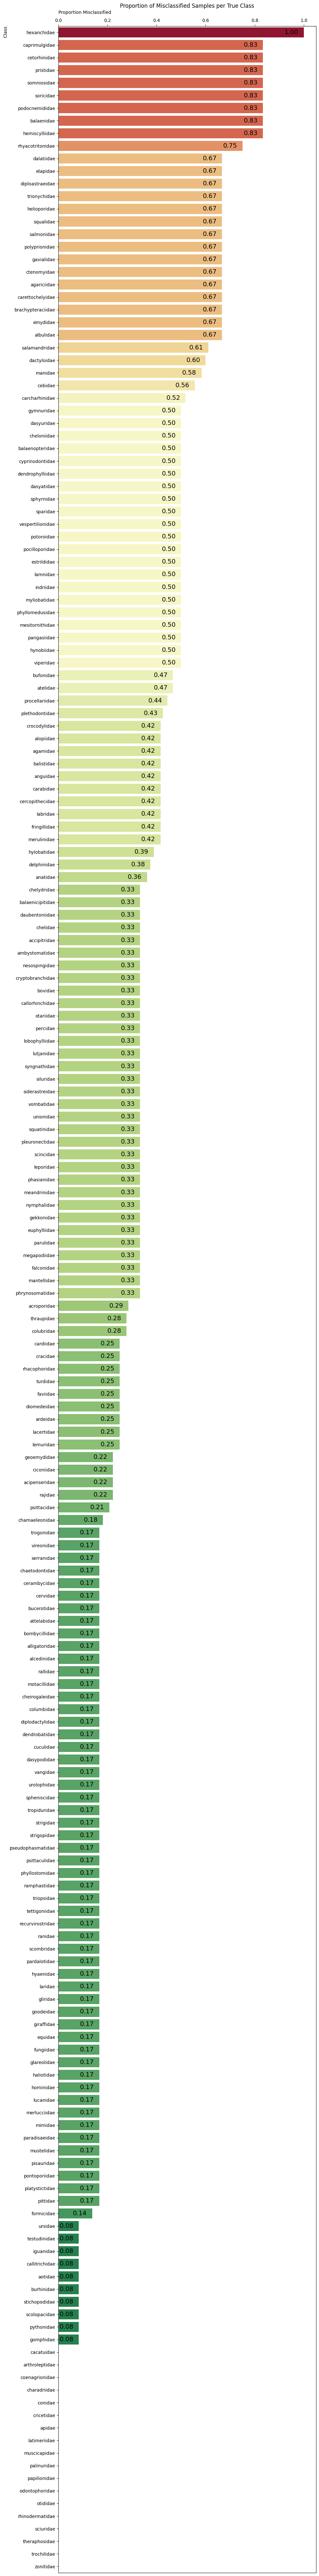

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

cm = confusion_matrix(y_true_classes, y_pred_classes)
labels = sorted(np.unique(np.concatenate((y_true_classes, y_pred_classes))))
total_per_class = cm.sum(axis=1)
misclassified = total_per_class - np.diag(cm)
proportion_misclassified = misclassified / total_per_class

# Create DataFrame without sorting immediately
df_misclassified = pd.DataFrame({
    'Class': labels,
    'Proportion Misclassified': proportion_misclassified
})

# Now sort the DataFrame based on 'Proportion Misclassified' after it's been created
df_misclassified = df_misclassified.sort_values(by='Proportion Misclassified', ascending=False)

# Normalize for color mapping
norm = Normalize(vmin=proportion_misclassified.min(), vmax=proportion_misclassified.max())
cmap = plt.cm.RdYlGn_r
colors = [cmap(norm(val)) for val in df_misclassified['Proportion Misclassified']]

plt.figure(figsize=(10, 80))
ax = sns.barplot(x='Proportion Misclassified', y='Class', data=df_misclassified,
                 palette=colors, order=df_misclassified['Class'], orient='h')

for index, value in enumerate(df_misclassified['Proportion Misclassified']):
    if value > 0:
        ax.text(value - 0.05, index, f'{value:.2f}', color='black', ha="center", va="center", fontsize=14)

plt.title('Proportion of Misclassified Samples per True Class')
plt.ylabel('Class', loc='top')

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xlabel('Proportion Misclassified', labelpad=10, loc='left')
plt.yticks(ticks=np.arange(len(df_misclassified)), labels=df_misclassified['Class'].map(class_indices))

plt.tight_layout()
plt.show()


<Figure size 1000x8000 with 0 Axes>

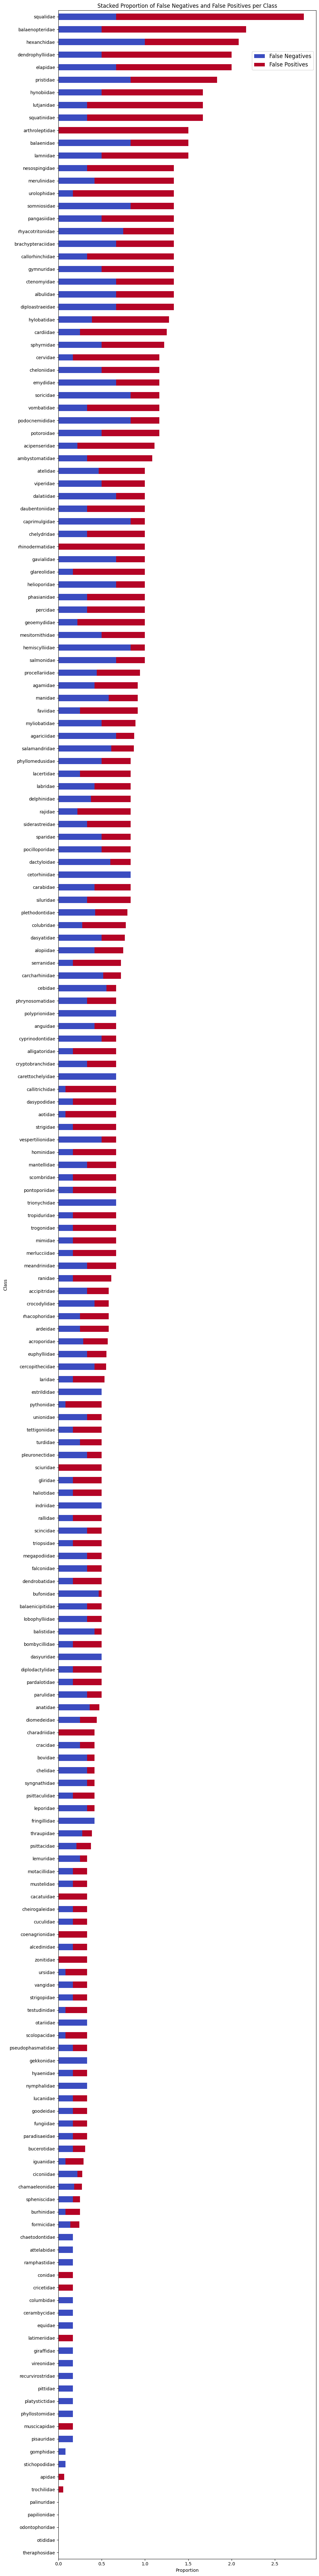

In [ ]:
#FIXME: THIS GRAPH IS NOT FOLLOWING THE CORRECT LABELLING SCHEMA, A FIX IS UNDERWAY, in our github if you care for it.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_classes, y_pred_classes)
labels = sorted(np.unique(np.concatenate((y_true_classes, y_pred_classes))))
tp = np.diag(cm)
fn = cm.sum(axis=1) - tp
fp = cm.sum(axis=0) - tp
total = cm.sum(axis=1)

prop_fn = fn / total
prop_fp = fp / total

df_misclassified = pd.DataFrame({
    'Class': labels,
    'False Negatives': prop_fn,
    'False Positives': prop_fp,
    'Total Misclassified': (fp + fn) / total
})

df_misclassified = df_misclassified.sort_values(by='Total Misclassified', ascending=False)
df_plot = df_misclassified.set_index('Class')[['False Negatives', 'False Positives']]

plt.figure(figsize=(10, 80))
ax = df_plot.plot(kind='barh', stacked=True, colormap='coolwarm', figsize=(10, 80))

plt.xlabel('Proportion')
plt.title('Stacked Proportion of False Negatives and False Positives per Class')
plt.gca().invert_yaxis()

plt.yticks(ticks=np.arange(len(df_misclassified)), labels=df_misclassified['Class'].map(class_indices))
plt.legend(loc='upper right', bbox_to_anchor=(1, 0.985), fontsize=12) 
plt.tight_layout()
plt.show()
